# MERFISH spatial analysis of the AON

The snRNA-seq data carry no spatial coordinates, so on their own they cannot place cells along
any AON axis. This notebook uses the Allen Brain Cell Atlas MERFISH data, which carry single-cell
CCF coordinates, to locate the five AON glutamatergic supertypes and to define the two spatial
axes that the differential-expression notebook then tests:

- **Anteroposterior (Z), the dominant molecular axis.** The transcriptomic supertypes separate
  most strongly along Z. This is reported first because it is the strongest signal in the data,
  not because it is the biological question.
- **Dorsolateral / ventromedial, the projection-relevant axis.** The biological question concerns
  contralaterally-projecting AON neurons. Prior viral tracing places the projection-dense
  population in the dorsolateral AON (pars dorsalis/lateralis). Illig & Eudy 2009, J Comp Neurol (rat tracing)
  corroborate a dorsolateral bias on the receiving side, though there the projecting neurons span
  all AON subregions. Projection status is not measured here, so a dorsolateral position is a
  spatial proxy for projection identity, not a readout of it. This axis is real but molecularly
  weaker than Z.

Both groupings are carried into the Allen 10x DE analysis, where the dorsolateral contrast is the
primary, projection-motivated result and the anteroposterior contrast serves as a robustness check.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path("..")
with open(ROOT / "config/config.yaml") as fh:
    cfg = yaml.safe_load(fh)
paths = cfg["paths"]

MERFISH_META = ROOT / paths["allen_merfish_meta"]

OUTPUT_DIR = ROOT / paths["results_dir"]
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures_raw"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

In [2]:
import plotting_style as ps

ps.apply_style()

In [3]:
import subprocess

_git_hash = subprocess.check_output(
    ["git", "rev-parse", "--short", "HEAD"], cwd=".."
).decode().strip()

print(f"git commit : {_git_hash}")
print(f"pandas     : {pd.__version__}")

git commit : b473fae
pandas     : 2.3.3


## Load MERFISH metadata

The Allen Brain Cell Atlas MERFISH dataset contains ~3.9 million cells with CCF spatial
coordinates and pre-assigned cluster labels.

In [4]:
usecols = ['cell_label', 'x', 'y', 'z', 'cluster', 'supertype', 'subclass', 'brain_section_label']

merfish = pd.read_csv(
    MERFISH_META,
    usecols=usecols
)
print(f"Total MERFISH cells: {len(merfish):,}")

Total MERFISH cells: 3,938,808


## Filter to AON glutamatergic neurons

The Allen taxonomy defines five glutamatergic supertypes within the AON region under the
label "IT AON-TT-DP Glut" (intratelencephalic, AON / taenia tecta / dorsal peduncular area).
These are the populations most relevant to the question of contralateral projections,
since the projection neurons of interest are glutamatergic.

In [5]:
aon = merfish[merfish['supertype'].str.contains('IT AON-TT-DP Glut', na=False)].copy()
print(f"AON glutamatergic cells: {len(aon):,}")

print("\nCluster distribution:")
print(aon['supertype'].value_counts().sort_index())

AON glutamatergic cells: 27,076

Cluster distribution:
supertype
0046 IT AON-TT-DP Glut_1     5905
0047 IT AON-TT-DP Glut_2     3808
0048 IT AON-TT-DP Glut_3     3706
0049 IT AON-TT-DP Glut_4     2236
0050 IT AON-TT-DP Glut_5    11421
Name: count, dtype: int64


In [6]:
aon['glut_cluster'] = aon['supertype'].str.extract(r'(Glut_\d+)$')

print("Brain section labels in AON glutamatergic cells:")
print(aon['brain_section_label'].value_counts().head(20))

Brain section labels in AON glutamatergic cells:
brain_section_label
C57BL6J-638850.57    3633
C57BL6J-638850.58    3539
C57BL6J-638850.60    3292
C57BL6J-638850.59    3166
C57BL6J-638850.62    3116
C57BL6J-638850.61    2618
C57BL6J-638850.56    2601
C57BL6J-638850.64    1993
C57BL6J-638850.54    1353
C57BL6J-638850.55    1298
C57BL6J-638850.51      77
C57BL6J-638850.52      69
C57BL6J-638850.50      39
C57BL6J-638850.39      28
C57BL6J-638850.49      26
C57BL6J-638850.48      24
C57BL6J-638850.45      21
C57BL6J-638850.44      18
C57BL6J-638850.46      18
C57BL6J-638850.47      17
Name: count, dtype: int64


## Spatial distribution by supertype

CCF coordinate orientation (Allen Mouse Brain CCF v3, Wang et al. 2020, Cell):
- **X**: medial -> lateral (distance from the midline, the axis a *contralateral* projection crosses)
- **Y**: dorsal -> ventral (inverted on plots so dorsal is at the top)
- **Z**: anterior -> posterior

All three axes are plotted so the separating axis is identified empirically rather than assumed.


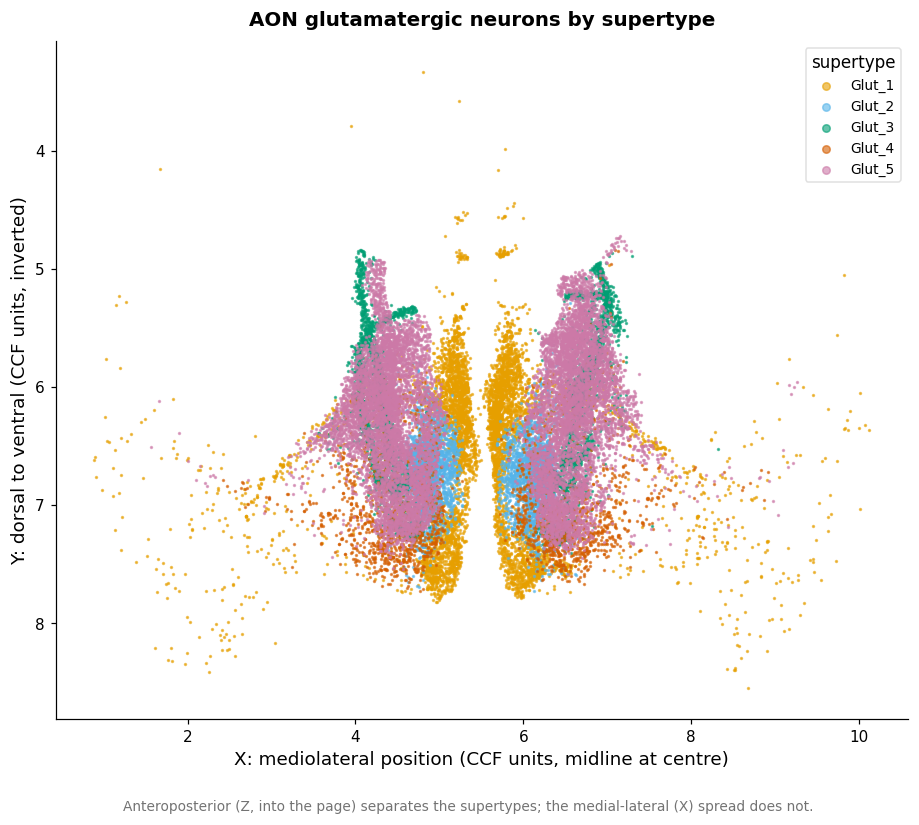

In [7]:
aon['glut_cluster'] = aon['supertype'].str.extract(r'(Glut_\d+)$')

cluster_order = sorted(aon['glut_cluster'].unique())
# Five perceptually distinct, colourblind-safe hues (no heavy black, no near-duplicate blues).
palette5 = ["#E69F00", "#56B4E9", "#009E73", "#D55E00", "#CC79A7"]
color_map = dict(zip(cluster_order, palette5))

fig, ax = plt.subplots(figsize=(10, 8))
for cluster in cluster_order:
    subset = aon[aon['glut_cluster'] == cluster]
    ax.scatter(subset['x'], subset['y'], c=color_map[cluster], label=cluster, s=1.5, alpha=0.6)

ax.set_xlabel('X: mediolateral position (CCF units, midline at centre)')
ax.set_ylabel('Y: dorsal to ventral (CCF units, inverted)')
ax.set_title('AON glutamatergic neurons by supertype', pad=10)
ax.legend(title='supertype', markerscale=4, loc='upper right', frameon=True, edgecolor='0.85')
ax.invert_yaxis()
fig.text(0.5, 0.005,
         'Anteroposterior (Z, into the page) separates the supertypes; the medial-lateral (X) '
         'spread does not.', ha='center', fontsize=9, color='0.45')
ps.save_fig(fig, FIG_DIR / "spatial_clusters", close=False)
plt.show()

## Axis 1: anteroposterior, the dominant molecular axis

The five Glut supertypes are defined transcriptomically (Allen taxonomy), independent of the CCF
coordinates, so asking whether supertype tracks anteroposterior (Z) position is non-circular. A
Kruskal-Wallis across supertypes with an epsilon-squared effect size quantifies it (with ~27k
cells the p-value is near zero regardless, so the effect size carries the meaning).

A supertype is labelled *posterior* if its median Z exceeds the Glut_2/Glut_3 midpoint, *anterior*
otherwise. Assigning at the supertype level (not a per-cell cutoff) keeps groups deterministic and
never splits a supertype against its own median. This supertype -> group mapping is exported as the
anteroposterior grouping for the DE robustness check.

In [8]:
from scipy.stats import kruskal

z_by_cluster = [g["z"].values for _, g in aon.groupby("glut_cluster", observed=True)]
h_stat, kw_p = kruskal(*z_by_cluster)
k = aon["glut_cluster"].nunique()
n = len(aon)
epsilon_sq = (h_stat - k + 1) / (n - k)
print("Does transcriptomic subtype track anteroposterior (Z) position?")
print(f"  Kruskal-Wallis across {k} Glut supertypes: H={h_stat:.0f}, p={kw_p:.1e}")
print(f"  Effect size (epsilon^2): {epsilon_sq:.3f}  (0.01 small, 0.06 medium, 0.14 large)")

supertype_z = aon.groupby("glut_cluster", observed=True)["z"].median().sort_index()
print("\nMedian Z (anterior->posterior) per supertype:")
print(supertype_z.round(2))

# Reproducible rule: a supertype is posterior if its median Z exceeds the midpoint of the two
# supertypes straddling the boundary (Glut_2, Glut_3), anterior otherwise. Applied at the
# supertype level so the grouping follows deterministically from the data.
z_threshold = (supertype_z["Glut_2"] + supertype_z["Glut_3"]) / 2

# The threshold recorded in config is the expected outcome of this rule. Fail loudly if a data or
# dependency change ever shifts it, rather than drifting silently from the config value.
assert abs(z_threshold - cfg["spatial"]["z_threshold"]) < 1e-9, (
    f"computed z_threshold {z_threshold}, config records {cfg['spatial']['z_threshold']}; "
    f"reconcile config/config.yaml or investigate the drift"
)

posterior_supertypes = supertype_z.index[supertype_z > z_threshold].tolist()
print(f"\nZ threshold (midpoint of Glut_2/Glut_3 medians): {z_threshold:.2f} CCF units")
print(f"Posterior supertypes (median Z > {z_threshold:.2f}): {posterior_supertypes}")

aon["group"] = np.where(aon["glut_cluster"].isin(posterior_supertypes), "posterior", "anterior")
print("\nGroup sizes (supertype-level assignment):")
print(aon["group"].value_counts())

# Export the supertype -> group mapping so the DE notebook loads it instead of hard-coding.
mapping = supertype_z.rename("median_z").reset_index().rename(columns={"glut_cluster": "supertype"})
mapping["group"] = np.where(mapping["supertype"].isin(posterior_supertypes), "posterior", "anterior")
OUTPUT_DIR.mkdir(exist_ok=True)
mapping.to_csv(TAB_DIR / "spatial_group_assignment.csv", index=False)
print(f"\nSaved supertype grouping to {TAB_DIR / 'spatial_group_assignment.csv'}")
print(mapping.to_string(index=False))

Does transcriptomic subtype track anteroposterior (Z) position?
  Kruskal-Wallis across 5 Glut supertypes: H=18416, p=0.0e+00
  Effect size (epsilon^2): 0.680  (0.01 small, 0.06 medium, 0.14 large)

Median Z (anterior->posterior) per supertype:
glut_cluster
Glut_1    10.8
Glut_2    11.0
Glut_3    12.2
Glut_4    11.0
Glut_5    11.8
Name: z, dtype: float64

Z threshold (midpoint of Glut_2/Glut_3 medians): 11.60 CCF units
Posterior supertypes (median Z > 11.60): ['Glut_3', 'Glut_5']

Group sizes (supertype-level assignment):
group
posterior    15127
anterior     11949
Name: count, dtype: int64

Saved supertype grouping to ../results/tables/spatial_group_assignment.csv
supertype  median_z     group
   Glut_1      10.8  anterior
   Glut_2      11.0  anterior
   Glut_3      12.2 posterior
   Glut_4      11.0  anterior
   Glut_5      11.8 posterior


In [9]:
# Per-sub-cluster medians confirm the split is a supertype-level summary, sub-clusters vary within a supertype.
sub = (aon.groupby("cluster", observed=True)
          .agg(n=("z", "size"), med_x=("x", "median"),
               med_y=("y", "median"), med_z=("z", "median")))
sub["supertype"] = sub.index.str.extract(r"(Glut_\d+)$", expand=False)
sub["group"] = np.where(sub["supertype"].isin(posterior_supertypes), "posterior", "anterior")
print("Per-sub-cluster CCF medians (X med->lat, Y dorsal->ventral, Z ant->post):")
print(sub.sort_values("med_z").round(2).to_string())

Per-sub-cluster CCF medians (X med->lat, Y dorsal->ventral, Z ant->post):
                             n  med_x  med_y  med_z supertype      group
cluster                                                                 
0168 IT AON-TT-DP Glut_1   380   5.49   7.29    9.7    Glut_1   anterior
0166 IT AON-TT-DP Glut_1   397   5.66   6.04   10.2    Glut_1   anterior
0169 IT AON-TT-DP Glut_1   910   5.58   5.88   10.2    Glut_1   anterior
0167 IT AON-TT-DP Glut_1  1273   5.65   6.11   10.8    Glut_1   anterior
0174 IT AON-TT-DP Glut_2    97   5.92   7.29   10.8    Glut_2   anterior
0170 IT AON-TT-DP Glut_1  2945   5.60   7.15   11.0    Glut_1   anterior
0171 IT AON-TT-DP Glut_2  2458   5.15   6.66   11.0    Glut_2   anterior
0172 IT AON-TT-DP Glut_2   809   5.26   6.71   11.0    Glut_2   anterior
0173 IT AON-TT-DP Glut_2   444   4.99   7.06   11.0    Glut_2   anterior
0181 IT AON-TT-DP Glut_4   578   5.95   7.22   11.0    Glut_4   anterior
0180 IT AON-TT-DP Glut_4  1040   4.64   7.15   11.

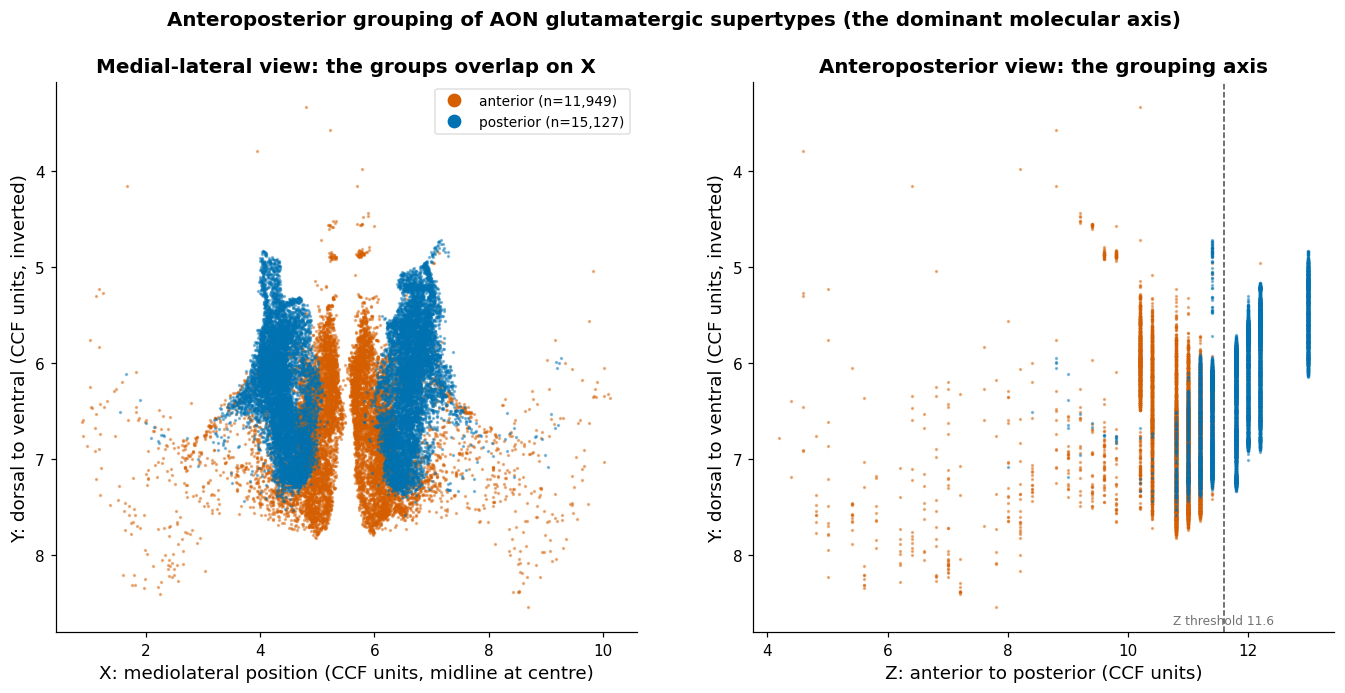

In [10]:
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
group_colors = {"anterior": ps.DIRECTION_COLORS["anterior"],
                "posterior": ps.DIRECTION_COLORS["posterior"]}
for group in ["anterior", "posterior"]:
    subset = aon[aon["group"] == group]
    ax1.scatter(subset["x"], subset["y"], c=group_colors[group], s=1.5, alpha=0.4)
    ax2.scatter(subset["z"], subset["y"], c=group_colors[group], s=1.5, alpha=0.4)

ax1.set_xlabel("X: mediolateral position (CCF units, midline at centre)")
ax1.set_ylabel("Y: dorsal to ventral (CCF units, inverted)")
ax1.set_title("Medial-lateral view: the groups overlap on X")
ax1.invert_yaxis()

ax2.axvline(z_threshold, color="0.3", linestyle="--", linewidth=1)
ax2.text(z_threshold, 0.01, f"Z threshold {z_threshold:.1f}", transform=ax2.get_xaxis_transform(),
         ha="center", va="bottom", fontsize=8, color="0.45")
ax2.set_xlabel("Z: anterior to posterior (CCF units)")
ax2.set_ylabel("Y: dorsal to ventral (CCF units, inverted)")
ax2.set_title("Anteroposterior view: the grouping axis")
ax2.invert_yaxis()

handles = [Line2D([0], [0], marker="o", ls="", color=group_colors[g], markersize=8,
                  label=f"{g} (n={(aon['group'] == g).sum():,})") for g in ["anterior", "posterior"]]
ax1.legend(handles=handles, loc="upper right", frameon=True, edgecolor="0.85", fontsize=9)
fig.suptitle("Anteroposterior grouping of AON glutamatergic supertypes (the dominant molecular axis)",
             fontsize=13, fontweight="bold")
ps.save_fig(fig, FIG_DIR / "spatial_posterior_anterior", close=False)
plt.show()

## Spatial statistics

Quantifying the spatial separation between the posterior and anterior groups across all three
CCF axes, to confirm the visual impression from the scatter plots and to show which axis
actually distinguishes them.

In [11]:
from scipy.stats import mannwhitneyu

spatial_stats = aon.groupby("group", observed=True)[["x", "y", "z"]].agg(["mean", "std"]).round(2)
print("Spatial statistics by group:")
print(spatial_stats)

post = aon[aon["group"] == "posterior"]
ant = aon[aon["group"] == "anterior"]
print("\nPosterior - anterior mean separation per axis (pooled SD in parentheses):")
for ax_name in ["x", "y", "z"]:
    d = post[ax_name].mean() - ant[ax_name].mean()
    print(f"  {ax_name}: {d:+.2f} CCF  (SD {aon[ax_name].std():.2f})")

# X and Y are independent of the Z-defined split, reported as corroboration.
u, p_y = mannwhitneyu(post["y"], ant["y"], alternative="two-sided")
rank_biserial = 1 - (2 * u) / (len(post) * len(ant))
print(f"\nIndependent Y-axis test: "
      f"Mann-Whitney p = {p_y:.1e}, rank-biserial r = {rank_biserial:.2f}")

Spatial statistics by group:
              x           y            z      
           mean   std  mean   std   mean   std
group                                         
anterior   5.49  0.94  6.70  0.58  10.78  0.70
posterior  5.49  1.17  6.24  0.59  11.92  0.56

Posterior - anterior mean separation per axis (pooled SD in parentheses):
  x: -0.00 CCF  (SD 1.08)
  y: -0.46 CCF  (SD 0.63)
  z: +1.14 CCF  (SD 0.85)

Independent Y-axis test: Mann-Whitney p = 0.0e+00, rank-biserial r = 0.42


## Axis 2: dorsolateral vs ventromedial, the projection-relevant axis

This is the axis the biological question turns on (the intro covers the tracing evidence and the projection-proxy caveat).

The dorsolateral score is coordinate-driven and reproducible. Fold X about each brain section's
midline (the AON is bilateral, so `|x - section median|` is lateral distance from the midline),
add a dorsal term (`-Y`, since Y runs dorsal->ventral), z-score both and sum. A cluster is
dorsolateral if its median score is in the top half of the 20 AON glut clusters. This is the
primary, projection-motivated contrast carried into the DE notebook.

In [12]:
# Coordinate-driven dorsolateral score: lateral distance from the per-section midline
# (fold X about each section median, since the AON is bilateral) plus a dorsal term (-Y).
aon["x_lat"] = aon.groupby("brain_section_label")["x"].transform(lambda s: (s - s.median()).abs())
aon["dorsal"] = -aon["y"]
zscore = lambda s: (s - s.mean()) / s.std()
aon["dl_score"] = zscore(aon["x_lat"]) + zscore(aon["dorsal"])

# Cluster-level split: dorsolateral if a cluster's median dl_score is in the top half.
cluster_dl = aon.groupby("cluster", observed=True)["dl_score"].median().sort_values(ascending=False)
n_dl = len(cluster_dl) // 2
dorsolateral_clusters = cluster_dl.index[:n_dl].tolist()
aon["dl_group"] = np.where(aon["cluster"].isin(dorsolateral_clusters),
                           "dorsolateral", "ventromedial")

dl_assign = (aon.groupby("cluster", observed=True)
                .agg(n=("dl_score", "size"), med_dl_score=("dl_score", "median"),
                     med_z=("z", "median"), med_y=("y", "median"), med_x_lat=("x_lat", "median"))
                .reset_index())
dl_assign["supertype"] = dl_assign["cluster"].str.extract(r"(Glut_\d+)$")
dl_assign["group"] = np.where(dl_assign["cluster"].isin(dorsolateral_clusters),
                              "dorsolateral", "ventromedial")
dl_assign = dl_assign.sort_values("med_dl_score", ascending=False)
OUTPUT_DIR.mkdir(exist_ok=True)
dl_assign.to_csv(TAB_DIR / "spatial_cluster_dl_assignment.csv", index=False)

print("Group sizes (cluster-level dorsolateral assignment):")
print(aon["dl_group"].value_counts())
print(f"\nSaved cluster grouping to {TAB_DIR / 'spatial_cluster_dl_assignment.csv'}")
print(dl_assign[["cluster", "n", "med_dl_score", "med_z", "group"]].round(2).to_string(index=False))

Group sizes (cluster-level dorsolateral assignment):
dl_group
dorsolateral    15769
ventromedial    11307
Name: count, dtype: int64

Saved cluster grouping to ../results/tables/spatial_cluster_dl_assignment.csv
                 cluster    n  med_dl_score  med_z        group
0175 IT AON-TT-DP Glut_3  892          1.23   13.0 dorsolateral
0176 IT AON-TT-DP Glut_3  428          0.95   12.2 dorsolateral
0178 IT AON-TT-DP Glut_3 1365          0.76   12.2 dorsolateral
0182 IT AON-TT-DP Glut_5  777          0.58   11.4 dorsolateral
0184 IT AON-TT-DP Glut_5 7859          0.53   12.0 dorsolateral
0185 IT AON-TT-DP Glut_5  847          0.47   11.8 dorsolateral
0177 IT AON-TT-DP Glut_3 1021          0.43   12.0 dorsolateral
0169 IT AON-TT-DP Glut_1  910          0.15   10.2 dorsolateral
0167 IT AON-TT-DP Glut_1 1273         -0.10   10.8 dorsolateral
0166 IT AON-TT-DP Glut_1  397         -0.17   10.2 dorsolateral
0168 IT AON-TT-DP Glut_1  380         -0.18    9.7 ventromedial
0180 IT AON-TT-DP Glu

In [13]:
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score


def epsilon_squared(values, labels):
    """Kruskal-Wallis epsilon-squared effect size of the grouping labels on values."""
    values, labels = np.asarray(values), np.asarray(labels)
    groups = [values[labels == g] for g in pd.unique(labels)]
    H, _ = kruskal(*groups)
    k, N = len(groups), len(values)
    return (H - k + 1) / (N - k)

print("Separability of each CCF axis (epsilon^2, higher = axis separates the groups more):")
print(f"{'axis':10s} {'across clusters':>16s} {'across supertypes':>18s}")
for ax_name in ["z", "y", "x_lat", "dl_score"]:
    e_cluster = epsilon_squared(aon[ax_name], aon["cluster"])
    e_super = epsilon_squared(aon[ax_name], aon["glut_cluster"])
    print(f"{ax_name:10s} {e_cluster:16.3f} {e_super:18.3f}")

auroc_z = roc_auc_score(aon["group"] == "posterior", aon["z"])
auroc_dl = roc_auc_score(aon["dl_group"] == "dorsolateral", aon["dl_score"])
rho = spearmanr(aon["dl_score"], aon["z"]).statistic
disagree = ((aon["dl_group"] == "dorsolateral") != (aon["group"] == "posterior")).mean()

print(f"\nAnteroposterior is the dominant molecular axis: "
      f"Z eps^2 {epsilon_squared(aon['z'], aon['cluster']):.2f}, "
      f"AUROC(Z; posterior vs anterior) {auroc_z:.2f}.")
print(f"Dorsolateral is real but weaker:                 "
      f"dl_score eps^2 {epsilon_squared(aon['dl_score'], aon['cluster']):.2f}, "
      f"AUROC(dl_score; DL vs VM) {auroc_dl:.2f}.")
print(f"The two axes are correlated (Spearman dl_score vs Z = {rho:.2f}); a cluster-level "
      f"dorsolateral\nsplit disagrees with supertype-posterior on {disagree:.0%} of cells.")

Separability of each CCF axis (epsilon^2, higher = axis separates the groups more):
axis        across clusters  across supertypes
z                     0.733              0.680
y                     0.369              0.161
x_lat                 0.167              0.128
dl_score              0.319              0.213

Anteroposterior is the dominant molecular axis: Z eps^2 0.73, AUROC(Z; posterior vs anterior) 0.96.
Dorsolateral is real but weaker:                 dl_score eps^2 0.32, AUROC(dl_score; DL vs VM) 0.80.
The two axes are correlated (Spearman dl_score vs Z = 0.50); a cluster-level dorsolateral
split disagrees with supertype-posterior on 17% of cells.


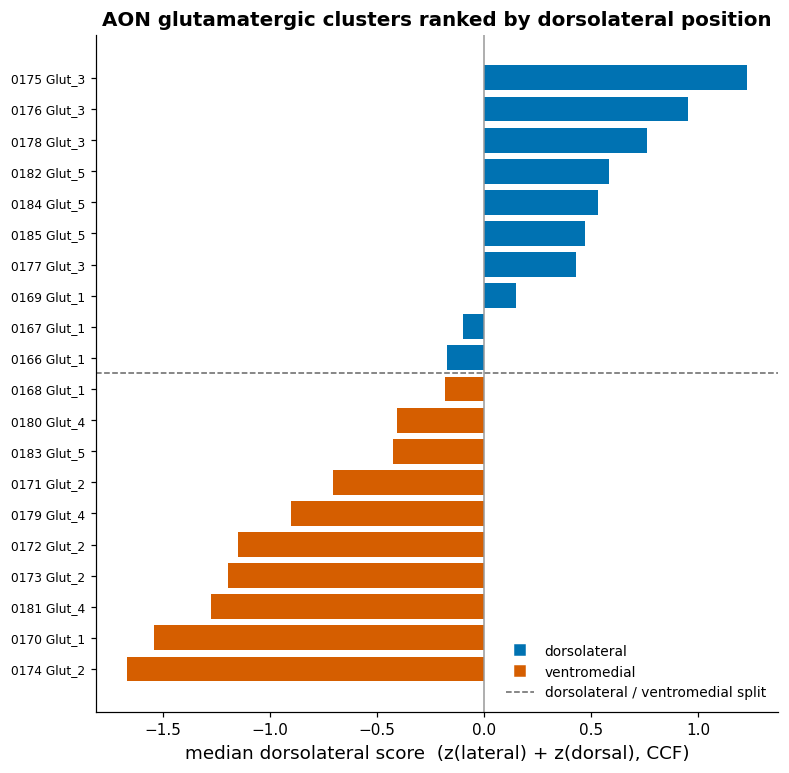

In [14]:
from matplotlib.lines import Line2D

order = dl_assign.sort_values("med_dl_score")
colors = order["group"].map(ps.DIRECTION_COLORS)
y = np.arange(len(order))
split_y = (y[(order["group"] == "ventromedial").values].max()
           + y[(order["group"] == "dorsolateral").values].min()) / 2

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(y, order["med_dl_score"], color=colors, zorder=2)
ax.axvline(0, color="0.6", lw=1)
ax.axhline(split_y, ls="--", color="0.4", lw=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{c.split()[0]} {s}" for c, s in zip(order["cluster"], order["supertype"])],
                   fontsize=8)
ax.set_xlabel("median dorsolateral score  (z(lateral) + z(dorsal), CCF)")
ax.set_title("AON glutamatergic clusters ranked by dorsolateral position")
handles = [Line2D([0], [0], marker="s", ls="", color=ps.DIRECTION_COLORS[g], label=g)
           for g in ["dorsolateral", "ventromedial"]]
handles.append(Line2D([0], [0], ls="--", color="0.4", lw=1,
                      label="dorsolateral / ventromedial split"))
ax.legend(handles=handles, loc="lower right")
ps.save_fig(fig, FIG_DIR / "spatial_dorsolateral_assignment", close=False)
plt.show()

## Summary

Two spatial axes are defined on the AON glutamatergic supertypes and exported for the DE notebook.

**Anteroposterior (Z), the dominant molecular axis.** The supertype-median-Z rule labels **Glut_3 and
Glut_5 posterior** and **Glut_1, Glut_2, Glut_4 anterior**, exported to
`results/tables/spatial_group_assignment.csv`. This matches independent evidence that olfactory-cortex
glutamatergic identity is graded primarily along Z (Zeppilli et al. 2025, Nat Neurosci; Chen et al. 2022, Cell).

**Dorsolateral / ventromedial, the projection-relevant axis.** The coordinate-based dorsolateral score
is exported to `results/tables/spatial_cluster_dl_assignment.csv`. It is a real axis (epsilon-squared and
AUROC above) but molecularly weaker than Z, correlated with it (Spearman ~0.5), and disagrees with the
supertype-posterior split on ~17% of cells.

Caveats:

- Projection status is a hypothesis, not a measurement. The dorsolateral molecular contrast is a
  spatial proxy. Soma position and projection target are known to dissociate in cortex (Klingler
  et al. 2019, Curr Biol; MERGE-seq, Xu et al. 2024, eLife), so the definitive test is retrograde-labelled snRNA-seq,
  the natural next step.
- The dorsolateral score is coordinate-based and objective. It disagrees with the prior
  hand-picked Target/Non-target list on the Glut_3/Glut_4 boundary (e.g. cluster 0175, a dorsal
  Glut_3, is dorsolateral by coordinates but was hand-labelled non-target). The DE notebook reports
  both definitions.